In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import networkx as nx
from scipy.spatial import distance_matrix
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.neighbors import NearestNeighbors

In [4]:
import rdata

In [5]:
from family_joining import GetTreeTopology
from integrate import trajectories
from varifold_distance import varifold_squared_distance_matrix
from visualization import plot_streamlines

In [6]:
from matplotlib import colormaps as cm
viridis = plt.get_cmap('viridis')

# Read data

In [7]:
# select trajectory
data_name = 'bifurcating'
color_palette = np.array( [(.8, .9, .5), (.2, .8, .5), (0., .6, .3), (.1, .1, 1.), (.7, .5, 1.)])
dim = 15
sigma_vis = .5
t_diffusion = 2. ** 4.6
radius = 4.5; k_neighbors = 40
integration_step = .1; discretization_step = .5; margin = 6.; select_curves = [209, 434]
# sigma_x = 66.; sigma_t = 1.21

# data_name = 'trifurcating'
# color_palette = np.array([(1., .9, 0.), (.8, .9, .5), (.2, .8, .5), (0., .6, .3), (.1, .1, 1.), (1., 0, .8), (.7, .5, 1.)])
# dim = 15
# sigma_vis = 1.5
# t_diffusion = 2. ** 8.2
# radius = 7.5; k_neighbors = 40
# integration_step = .3; discretization_step = 1.5; margin = 15.; select_curves = [447, 189]
# sigma_x = 180.; sigma_t = 1.16

# data_name = 'double_bifurcating' 
# color_palette = np.array([(1., .9, 0.), (.8, .9, .5), (.2, .8, .5), (0., .6, .3), (.3, .7, 1.), (.1, .5, .8), (.1, .1, 1.), (1., 0, .8), (.7, .5, 1.)])
# dim = 10
# sigma_vis = .5
# t_diffusion = 2. ** 6.7
# radius = 8.5; k_neighbors = 40
# integration_step = .15; discretization_step = .75; margin = 8.; select_curves = [415, 187]
# # sigma_x = 100.; sigma_t = 1.06

In [8]:
# read data
data = rdata.read_rds(f'./Datasets/{data_name}/dataset.rds')
n_cells, n_genes = data['expression'].Dim

expressions = np.zeros(data['expression'].Dim)
j = 0
for iter, i, x in zip(np.arange(len(data['expression'].i)), data['expression'].i, data['expression'].x): 
    expressions[i, j] = x
    if iter == data['expression'].p[j+1]: j += 1

velocities = np.zeros(data['rna_velocity'].Dim)
j = 0
for iter, i, v in zip(np.arange(len(data['rna_velocity'].i)), data['rna_velocity'].i, data['rna_velocity'].x): 
    velocities[i, j] = v
    if iter == data['rna_velocity'].p[j+1]: j += 1

initial = np.array([list(data['milestone_ids']).index(ms) for ms in data['progressions']['from']])
colors = color_palette[initial]

In [9]:
# pseudotime
milestone_lengths = [len([ms for ms in data['progressions']['from'] if ms==id]) for id in data['milestone_ids']]
initial_pseudotime = np.zeros_like(milestone_lengths)
id2i = {id:i for i, id in enumerate(data['milestone_ids'])}
for i in range(1, len(id2i)):
    id_from = data['milestone_network'].at[i, 'from']
    id_to = data['milestone_network'].at[i, 'to']
    initial_pseudotime[id2i[id_to]] = initial_pseudotime[id2i[id_from]] + milestone_lengths[id2i[id_from]]
pseudotime = np.array([initial_pseudotime[initial[i]] + p * milestone_lengths[initial[i]] for (i, p) in enumerate(data['progressions']['percentage'])])
pseudotime /= np.max(pseudotime) 

In [10]:
# paths from the root to the leaves
T = nx.DiGraph(zip(data['milestone_network']['from'], data['milestone_network']['to']))
r = [n for n in T.nodes if not T.in_degree(n)][0]
paths = [nx.shortest_path(T, r, n)[:-1] for n in T if T.out_degree(n)==0]

# Dimensionality reduction

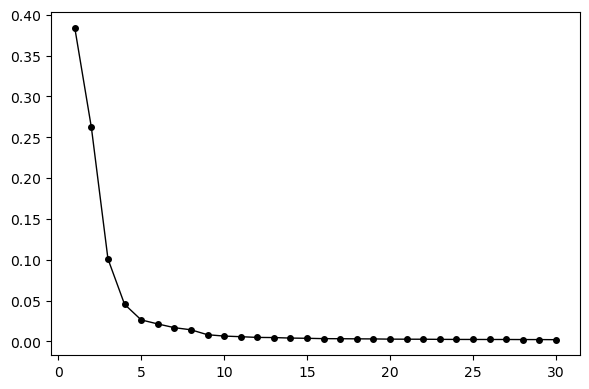

In [11]:
pca = PCA(n_components=30)
pca.fit(expressions)
fig = plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, 31), pca.explained_variance_ratio_, 'ko-', lw=1, ms=4)
fig.tight_layout()

pca = PCA(n_components=dim)
reduced_expressions = pca.fit_transform(expressions)
reduced_velocities = pca.transform(expressions + velocities) - reduced_expressions

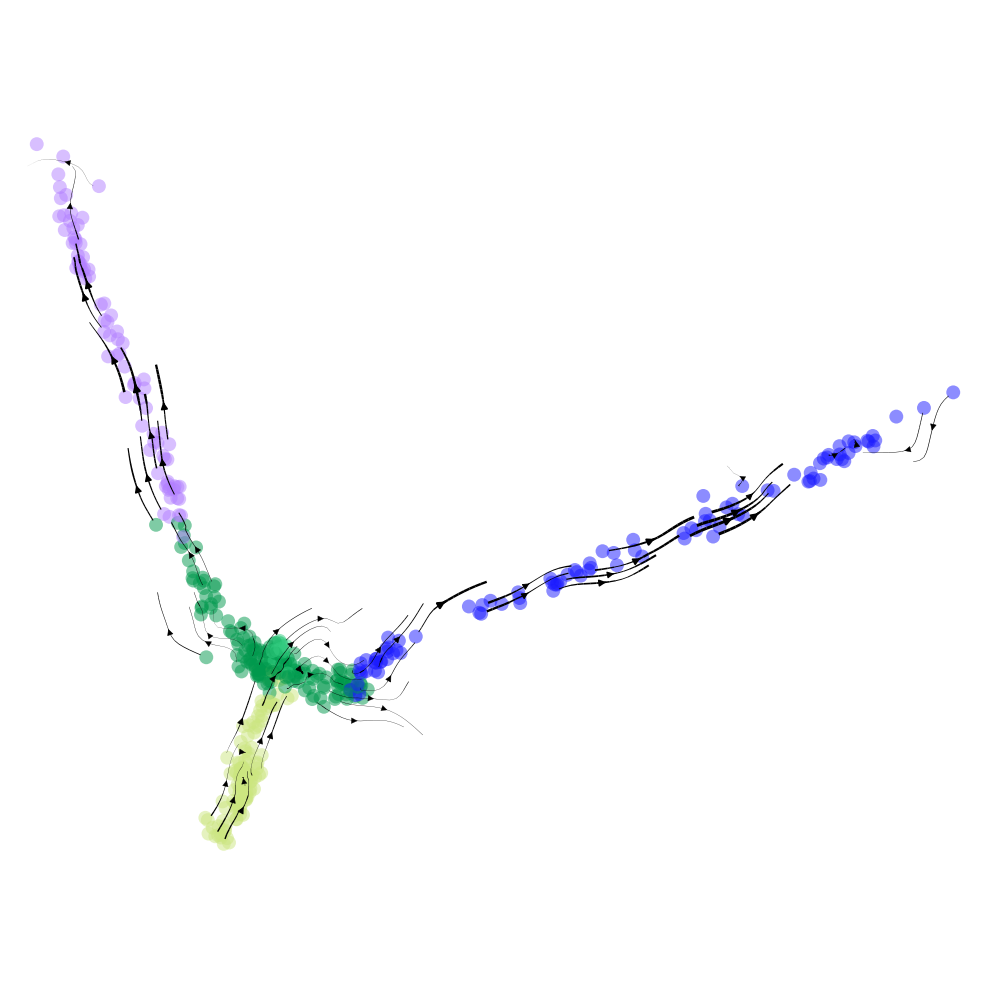

In [12]:
visualizer = PCA(n_components=2)
expressions_2D = visualizer.fit_transform(reduced_expressions)
velocities_2D = visualizer.transform(reduced_expressions + reduced_velocities) - expressions_2D

fig = plt.figure(figsize=(10, 10))
plt.scatter(expressions_2D[:, 0], expressions_2D[:, 1], s=100, color=colors, alpha=.5, linewidths=0)
plot_streamlines(expressions_2D, velocities_2D, sigma=sigma_vis)
plt.axis('equal')
plt.axis('off')
fig.tight_layout()

# Preprocessing of the RNA velocity field

### Smoothing

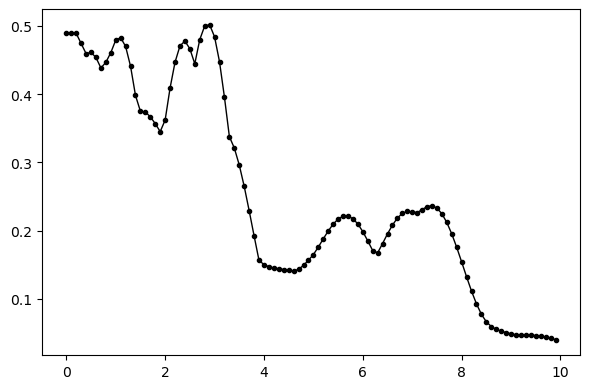

In [13]:
# tuning the diffusion time 
def heat_kernel(alpha, eps, normalized=True):

    K = np.exp(-distance_matrix(reduced_expressions, reduced_expressions) ** 2 / eps)

    if alpha == 0: Q_inv = np.eye(n_cells)
    if alpha == 1: Q_inv = np.diag(1. / np.sum(K, axis=1))

    K_alpha = Q_inv @ K @ Q_inv
    D_inv = np.diag(1. / np.sum(K_alpha, axis=1))

    return (D_inv @ K_alpha) if normalized else K_alpha

# plot semi-group error
fig = plt.figure(figsize=(6, 4))
T = 2. ** np.arange(0., 10., .1)
operator_norm = lambda A: np.linalg.norm(A, 2)
# SGE = [operator_norm(np.linalg.matrix_power(heat_kernel(alpha=1, eps=t), 2) - heat_kernel(alpha=1, eps=2.*t)) for t in T]
plt.plot(np.log2(T), SGE, 'ko-', lw=1, ms=3)
fig.tight_layout()

P = heat_kernel(alpha=1, eps=t_diffusion)
smoothed_velocities = np.linalg.matrix_power(P, 1) @ reduced_velocities

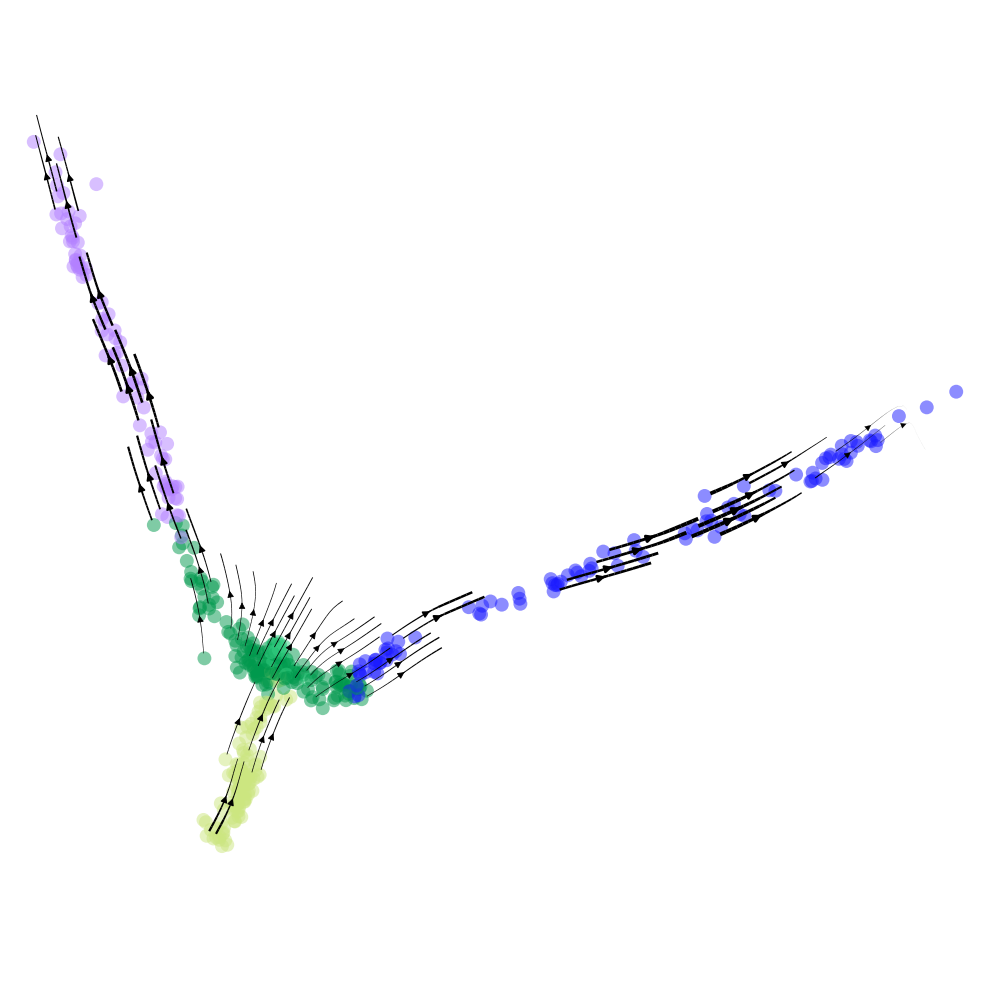

In [14]:
visualizer = PCA(n_components=2)
expressions_2D = visualizer.fit_transform(reduced_expressions)
velocities_2D = visualizer.transform(reduced_expressions + smoothed_velocities) - expressions_2D

fig = plt.figure(figsize=(10, 10))
plt.scatter(expressions_2D[:, 0], expressions_2D[:, 1], s=100, color=colors, alpha=.5, linewidths=0)
plot_streamlines(expressions_2D, velocities_2D, sigma=sigma_vis)
plt.axis('equal')
plt.axis('off')
fig.tight_layout()

### Tangent projection

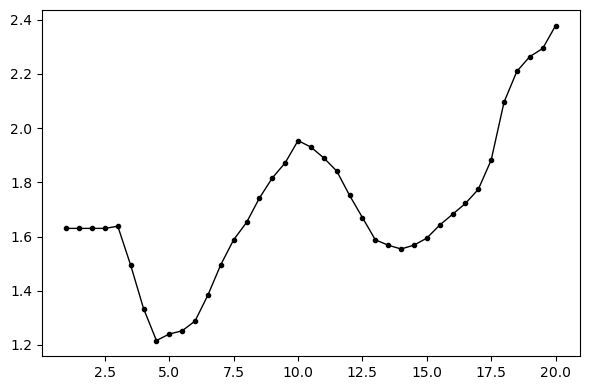

In [15]:
# tuning the neighborhood's size for the tangent space estimation
pca = PCA(n_components=dim)
radii = np.linspace(1., 20., 39)
local_dim = np.zeros_like(radii)

for i_r in range(len(radii)):
    nn = NearestNeighbors(radius=radii[i_r])
    neighbors = nn.fit(reduced_expressions).radius_neighbors(reduced_expressions, return_distance=False)

    for i in range(n_cells):
        neighbors_i = list(neighbors[i])
        if len(neighbors_i) < k_neighbors+1: neighbors_i = list(NearestNeighbors(n_neighbors=k_neighbors+1).fit(reduced_expressions).kneighbors([reduced_expressions[i]], return_distance=False)[0])
        neighbors_i.remove(i)
        
        pca.fit(reduced_expressions[neighbors_i])
        dim_i = np.argmax(np.array([pca.explained_variance_[d] / pca.explained_variance_[d+1] for d in range(pca.n_components - 1) if pca.explained_variance_ratio_[d] > .05])) + 1
        local_dim[i_r] += dim_i

    local_dim[i_r] /= n_cells

fig = plt.figure(figsize=(6, 4))
plt.plot(radii, local_dim, 'ko-', lw=1, ms=3)
fig.tight_layout()

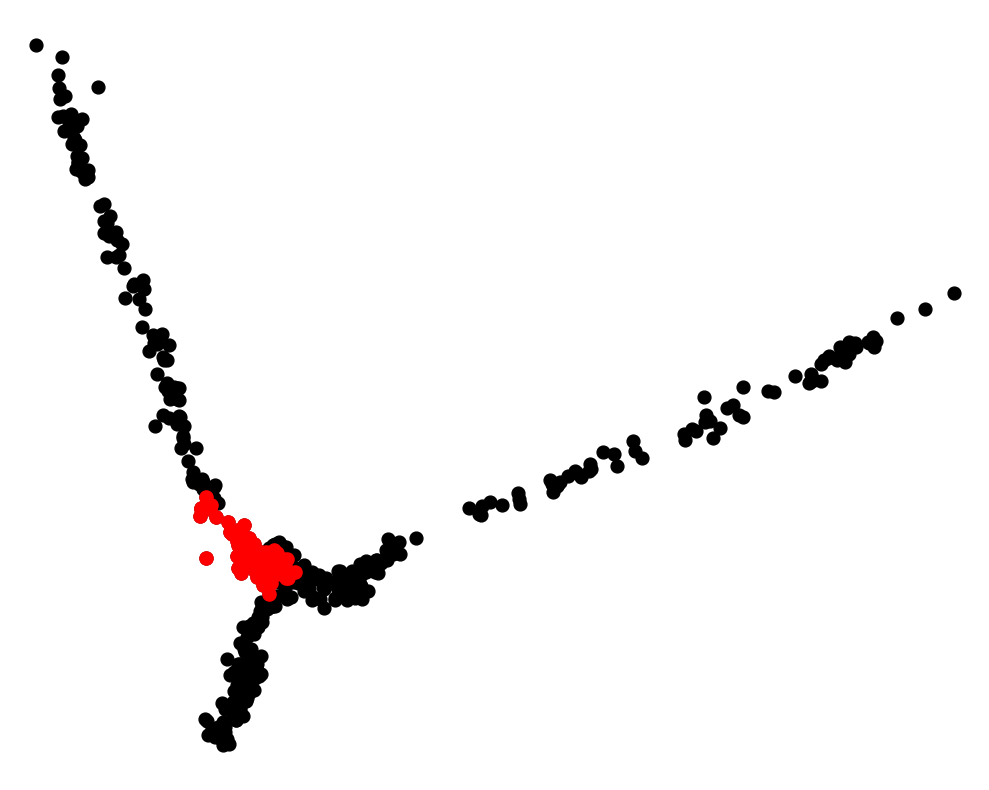

In [16]:
#visualizing neighborhoods
nn = NearestNeighbors(radius=radius)
i = np.random.randint(n_cells)
neighbors_i = nn.fit(reduced_expressions).radius_neighbors([reduced_expressions[i]], return_distance=False)[0]
if len(neighbors_i) < k_neighbors+1: neighbors_i = list(NearestNeighbors(n_neighbors=k_neighbors+1).fit(reduced_expressions).kneighbors([reduced_expressions[i]], return_distance=False)[0])

fig = plt.figure(figsize=(10, 8))
plt.scatter(expressions_2D[:, 0], expressions_2D[:, 1], s=85, color='k')
plt.scatter(expressions_2D[neighbors_i, 0], expressions_2D[neighbors_i, 1], s=90, color='r')
plt.axis('equal')
plt.axis('off')
fig.tight_layout()

In [17]:
# tangent projection
pca = PCA(n_components=dim)
nn = NearestNeighbors(radius=radius)
neighbors = nn.fit(reduced_expressions).radius_neighbors(reduced_expressions, return_distance=False)
projected_velocities = np.zeros_like(smoothed_velocities)
local_dim = []

for i in range(n_cells):
    neighbors_i = list(neighbors[i])
    if len(neighbors_i) < k_neighbors+1: neighbors_i = list(NearestNeighbors(n_neighbors=k_neighbors+1).fit(reduced_expressions).kneighbors([reduced_expressions[i]], return_distance=False)[0])
    neighbors_i.remove(i)
    
    pca.fit(reduced_expressions[neighbors_i])
    dim_i = np.argmax(np.array([pca.explained_variance_[d] / pca.explained_variance_[d+1] for d in range(pca.n_components - 1) if pca.explained_variance_ratio_[d] > .05])) + 1
    local_dim.append(dim_i)
    
    V = pca.components_[:dim_i]
    for v in V: projected_velocities[i] += np.dot(smoothed_velocities[i], v) * v

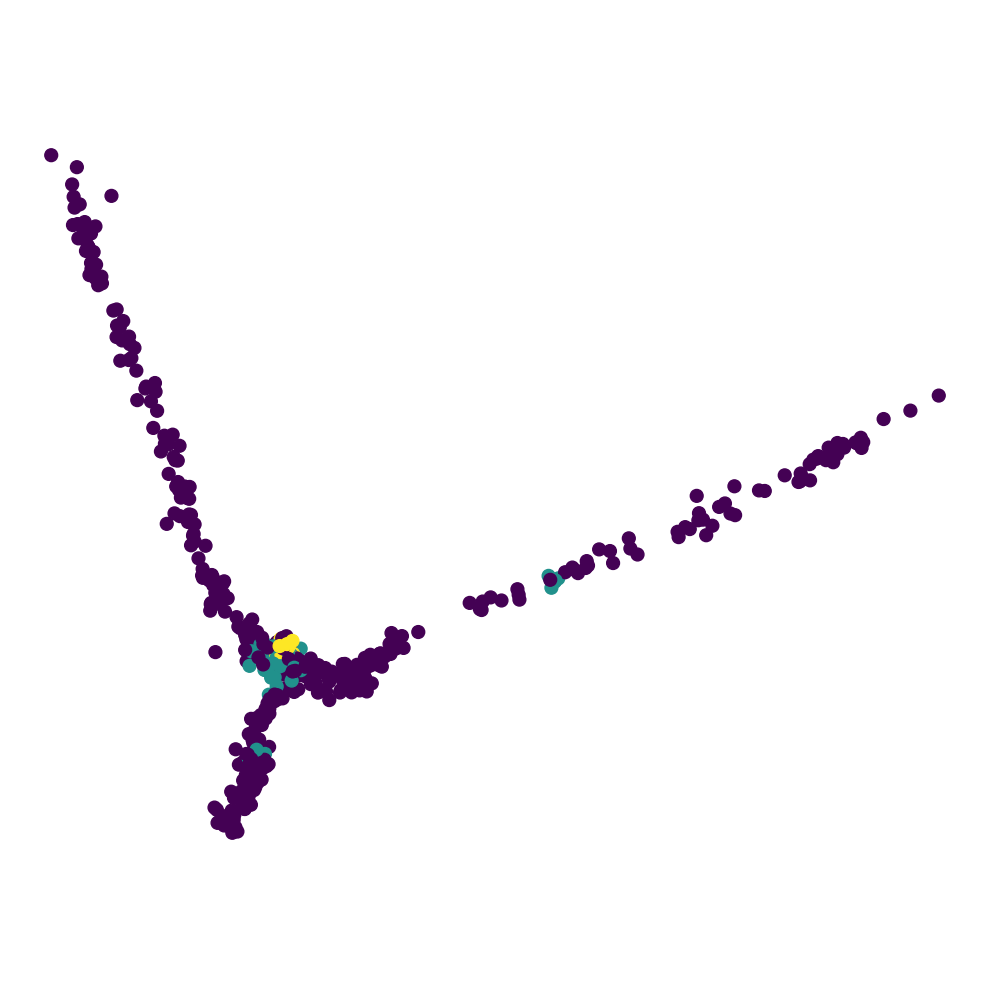

In [18]:
# visualizing the local dimension
from matplotlib import colormaps as cm
viridis = plt.get_cmap('viridis')

fig = plt.figure(figsize=(10, 10))

plt.scatter(expressions_2D[:, 0], expressions_2D[:, 1], s=85, color=viridis((np.array(local_dim) - 1.) / 2.))
plt.axis('equal')
plt.axis('off')
fig.tight_layout()

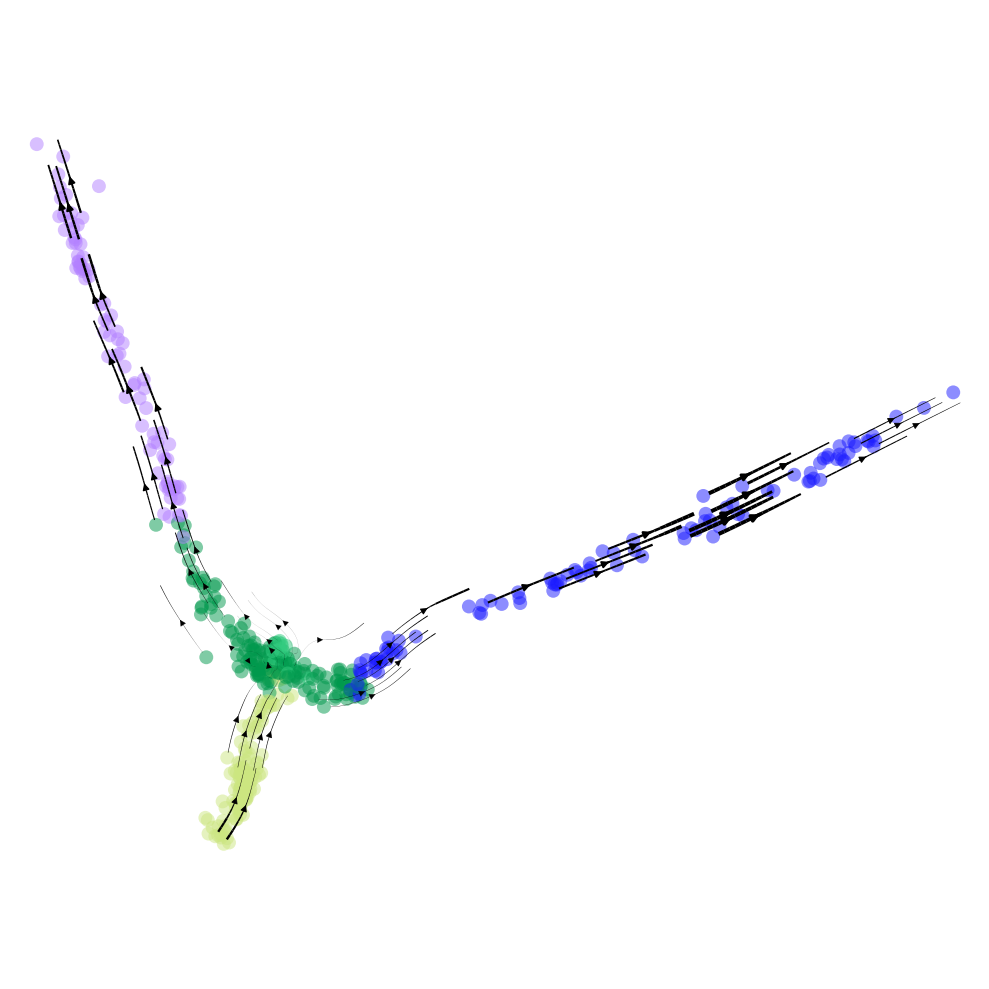

In [19]:
visualizer = PCA(n_components=2)
expressions_2D = visualizer.fit_transform(reduced_expressions)
velocities_2D = visualizer.transform(reduced_expressions + projected_velocities) - expressions_2D

fig = plt.figure(figsize=(10, 10))
plt.scatter(expressions_2D[:, 0], expressions_2D[:, 1], s=100, color=colors, alpha=.5, linewidths=0)
plot_streamlines(expressions_2D, velocities_2D, sigma=sigma_vis)
plt.axis('equal')
plt.axis('off')
fig.tight_layout()

# Integrating the RNA velocity field

In [20]:
curves = trajectories(reduced_expressions, projected_velocities, sigma=radius/3., integration_step=integration_step, discretization_step=discretization_step, margin=margin)

end_points = np.array([curve[-1] for curve in curves])
end_vectors = np.array([(curve[-1] - curve[-2]) / np.linalg.norm(curve[-1] - curve[-2]) for curve in curves if len(curve) > 1])

print("maximal length of the integral curves", np.quantile(np.array([len(curve) for curve in curves]), q=.95))
print("maximal deviation of the expressions:", np.max(distance_matrix(reduced_expressions, reduced_expressions)))
print("maximal deviation of the end points of the integral curves:", np.quantile(distance_matrix(end_points, end_points), q=.95))
print("maximal deviation of the end vectors of the integral curves:", np.quantile(distance_matrix(end_vectors, end_vectors), q=.95))

maximal length of the integral curves 93.0
maximal deviation of the expressions: 36.71376644482124
maximal deviation of the end points of the integral curves: 6.610472344135657
maximal deviation of the end vectors of the integral curves: 0.017999241246788557


In [21]:
# tuning sigma_x
dev_x = np.quantile(distance_matrix(end_points, end_points), q=.95)
sigma_x = 10. * dev_x
print("sigma_x =", sigma_x)

sigma_x = 66.10472344135657


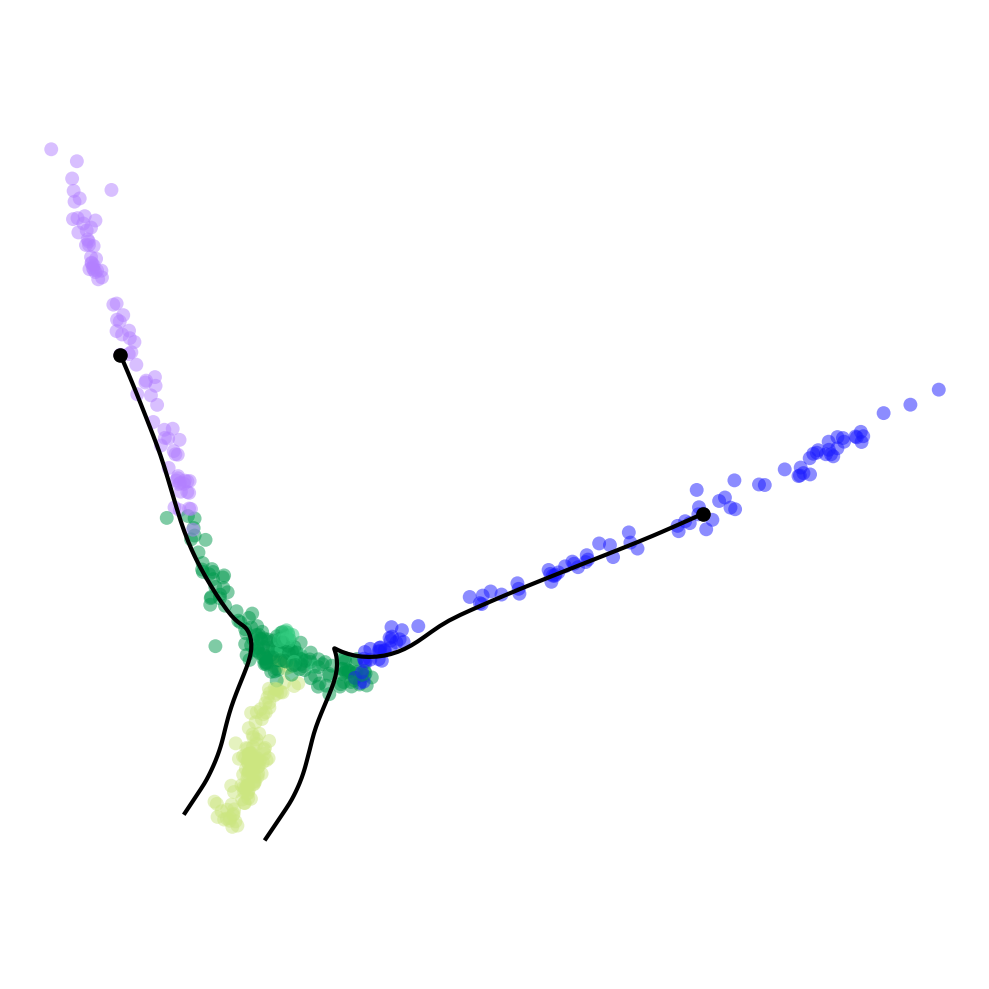

In [22]:
visualizer = PCA(n_components=2)
expressions_2D = visualizer.fit_transform(reduced_expressions)

fig = plt.figure(figsize=(10, 10))
plt.scatter(expressions_2D[:, 0], expressions_2D[:, 1], s=100, color=colors, alpha=.5, linewidths=0)
plt.scatter(expressions_2D[select_curves, 0], expressions_2D[select_curves, 1], color='k', s=90)
for i in select_curves: 
    curve_2D = visualizer.transform(curves[i])
    plt.plot(curve_2D[:, 0], curve_2D[:, 1], c='k', lw=3, zorder=2)
plt.axis('equal')
plt.axis('off')
fig.tight_layout()

sigma_t = 1.2100000000000009
 


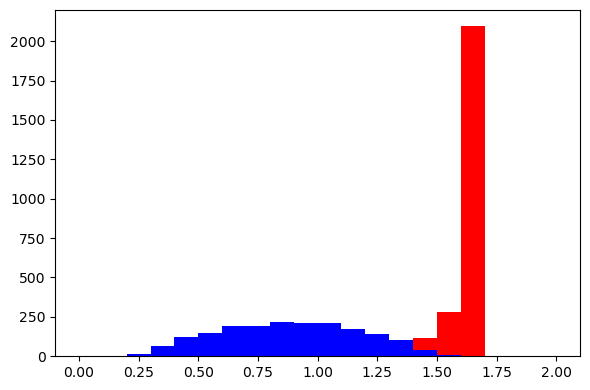

In [23]:
# tuning sigma_t
l_80 = np.quantile(np.array([len(curve) for curve in curves]), q=.8)
dev_t_between_paths = []
dev_t_within_path = []

for i in range(n_cells):
    for j in range(i+1, n_cells):
        l = min(len(curves[i]), len(curves[j]))
        
        # we compare only the longest curves i.e. those leading to leaf cells
        if l > l_80 and np.linalg.norm(curves[i][-1] - curves[j][-1]) < dev_x:
            dev_ij = np.array([np.linalg.norm((curves[i][-t] - curves[i][-(t+1)]) / np.linalg.norm(curves[i][-t] - curves[i][-(t+1)]) 
                                              - (curves[j][-t] - curves[j][-(t+1)]) / np.linalg.norm(curves[j][-t] - curves[j][-(t+1)])) 
                               for t in range(1, l)])
            
            if np.max(np.linalg.norm(curves[i][-l:] - curves[j][-l:], axis=1)) > dev_x: dev_t_between_paths.append(np.max(dev_ij))
            else: dev_t_within_path.append(np.max(dev_ij))            
            
fig = plt.figure(figsize=(6, 4))
plt.hist(dev_t_between_paths, bins=np.arange(0., 2.01, .1), color='r')
plt.hist(dev_t_within_path, bins=np.arange(0., 2.01, .1), color='b')
fig.tight_layout()

sigma_t = np.arange(.4, 4.01, .01)[np.argmax(np.array([np.exp(-(np.mean(dev_t_within_path)**2)/(s_t**2)) - np.exp(-(np.mean(dev_t_between_paths)**2)/(s_t**2)) for s_t in np.arange(.4, 4.01, .01)]))]
print('sigma_t =' , sigma_t)
print(' ')

# Dissimilarity matrix

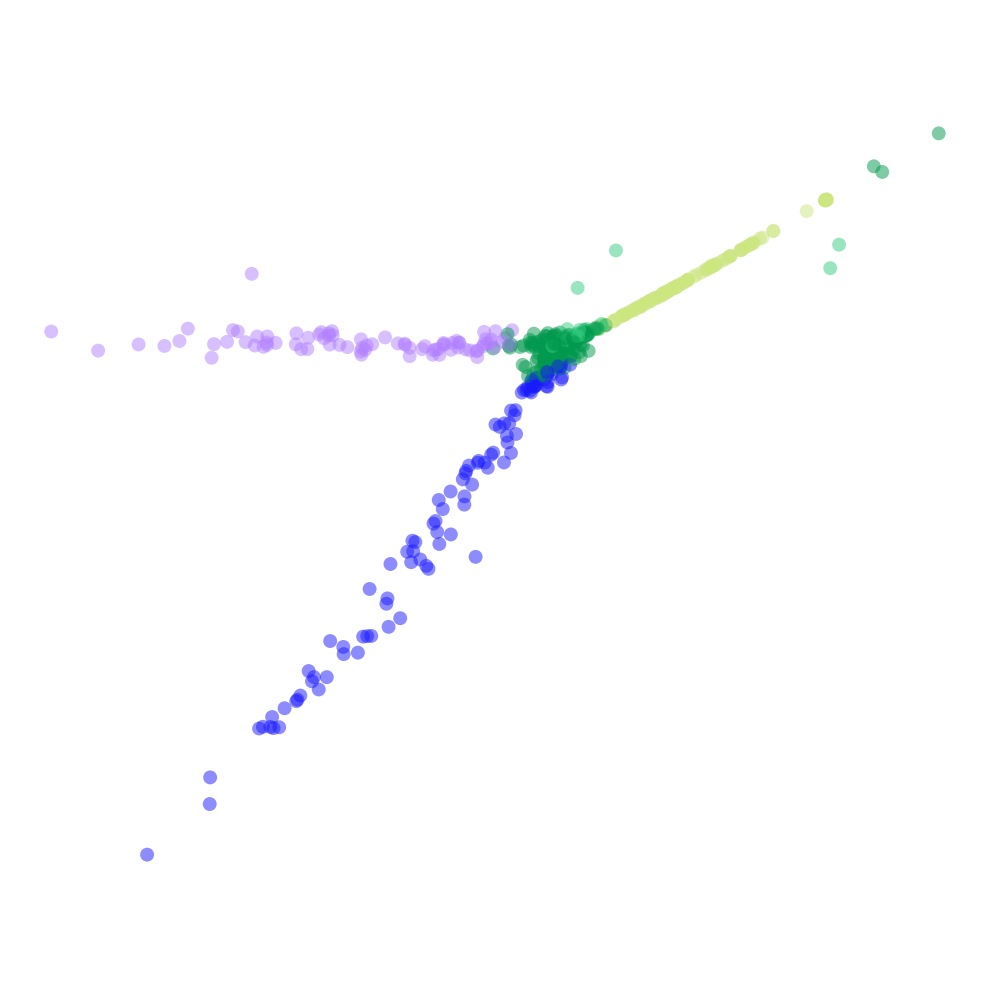

In [24]:
D = varifold_squared_distance_matrix(curves, sigma_x=sigma_x, sigma_t=sigma_t)

mds = MDS(n_components=2, dissimilarity='precomputed', random_state=0)
vis = mds.fit_transform(D)

fig = plt.figure(figsize=(10, 10))
plt.scatter(vis[:, 0], vis[:, 1], s=100, c=colors, alpha=.5, linewidths=0)
plt.axis('equal')
plt.axis('off')
plt.tight_layout()

# Differentiation tree inference

In [25]:
E = GetTreeTopology(D, eps=np.mean(D) / 10.)
G = nx.from_edgelist(E)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 497/499 [00:00<00:00, 1559.92step/s]


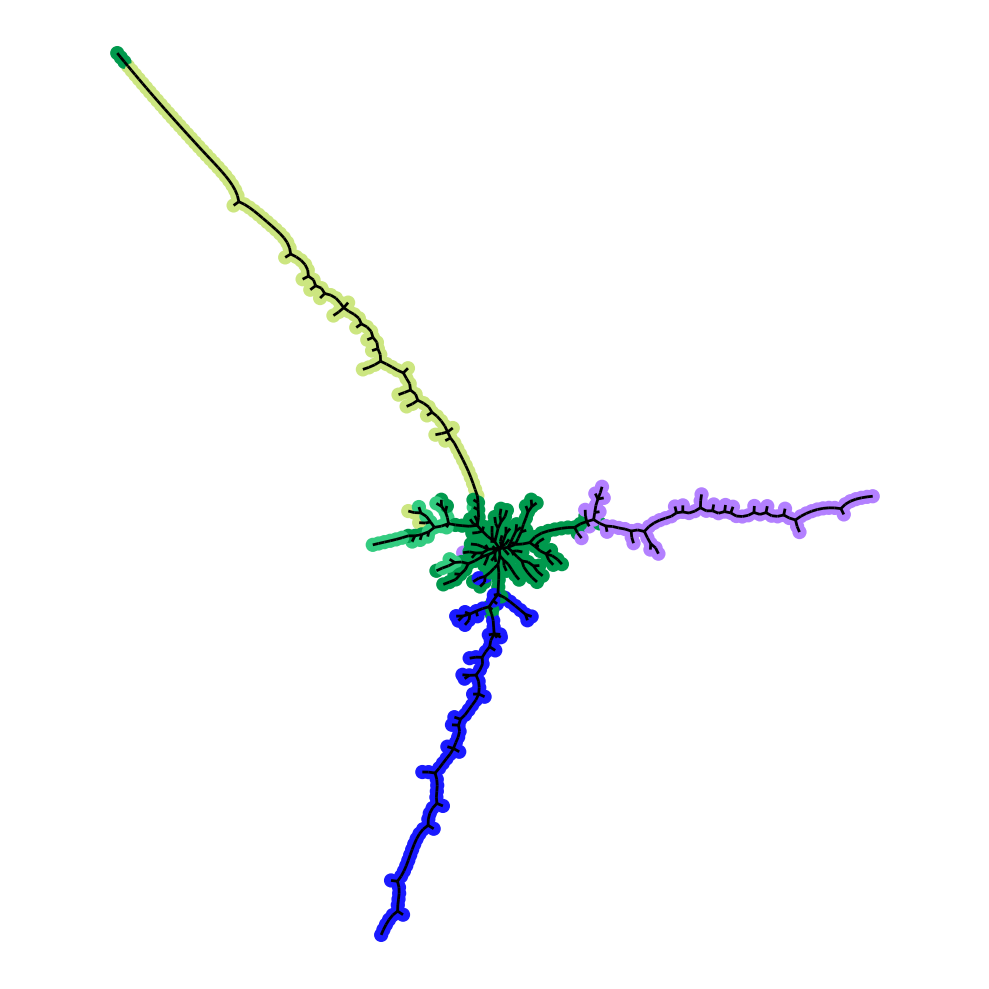

In [26]:
layout = nx.kamada_kawai_layout(G, weight=None)
layout = np.array(list(layout.values()))[np.argsort(list(layout.keys()))]

fig, ax = plt.subplots(figsize=(10, 10))

plt.scatter(*layout.T, s=85, c=colors)
from matplotlib.collections import LineCollection
ax.add_collection(LineCollection(layout[E], color='k', lw=2))

plt.axis('equal')
plt.axis('off')
fig.tight_layout()

# Evaluation

average percentage of well-ordered cells: 0.885857876957161
 


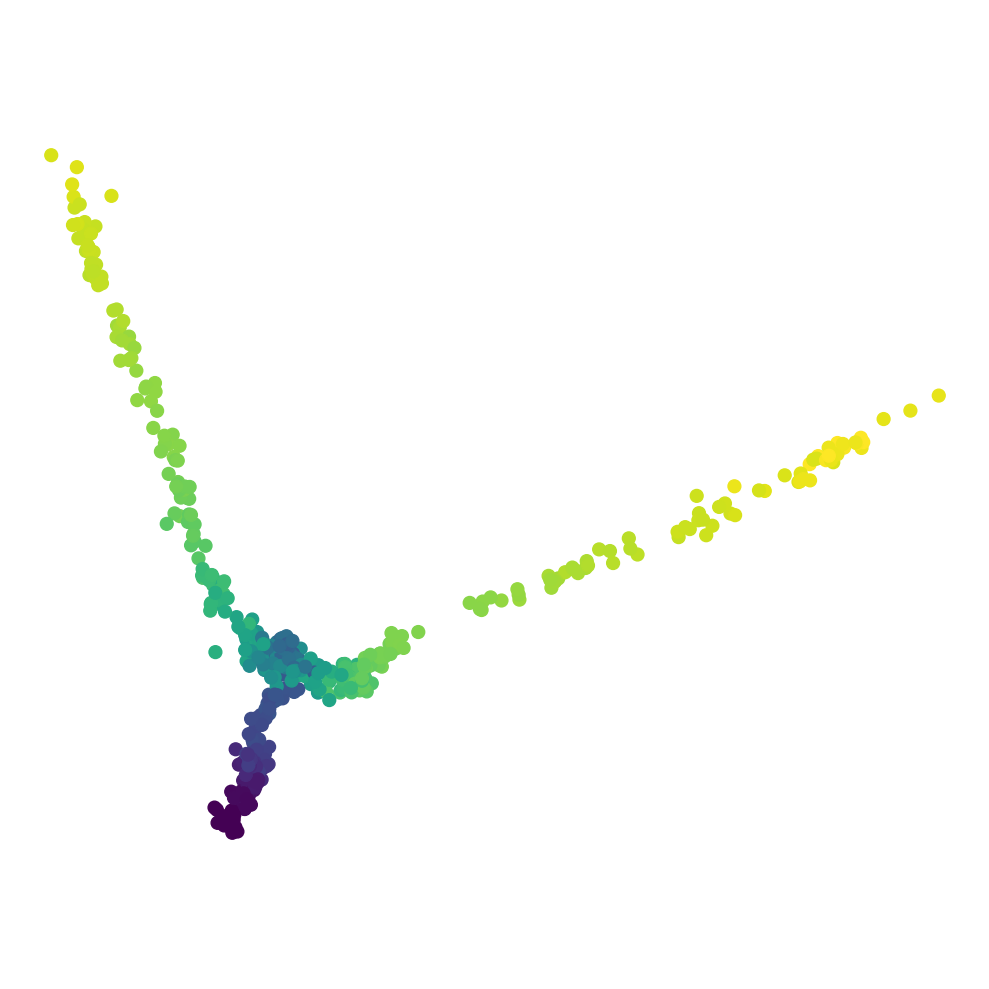

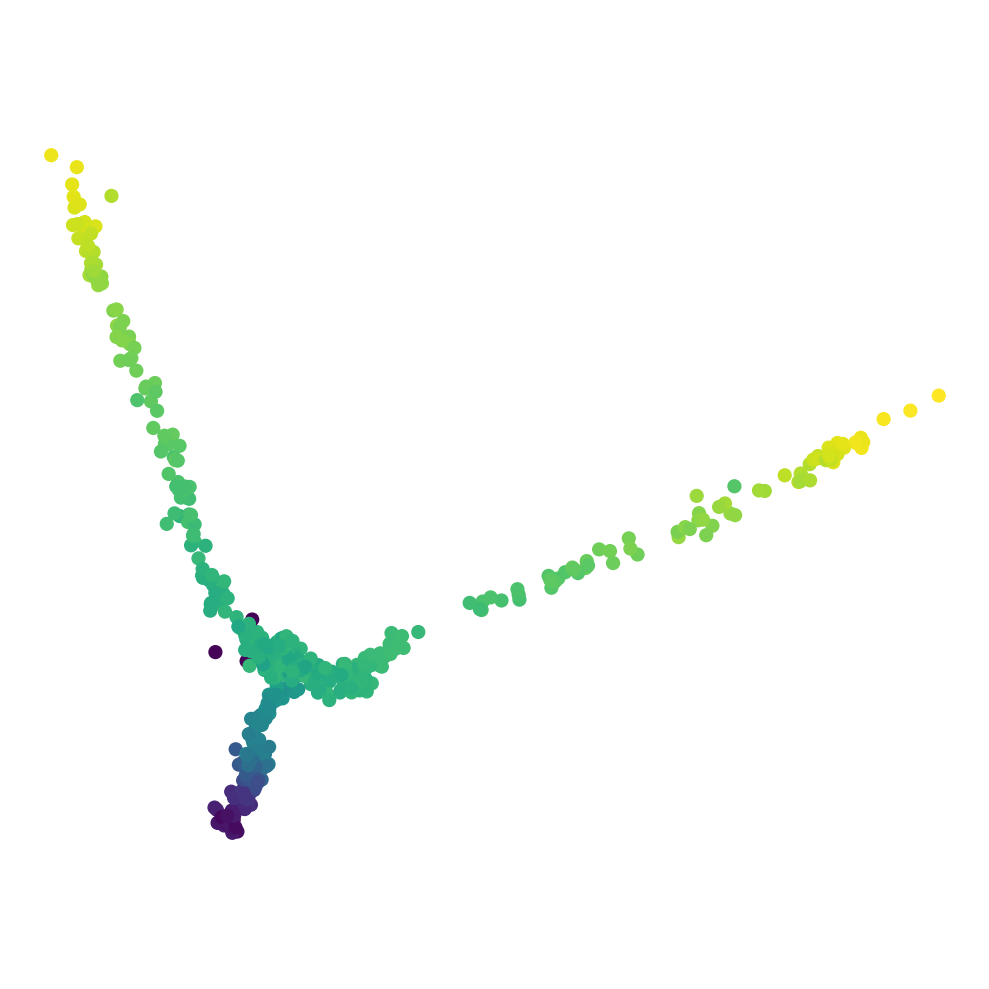

In [27]:
roots = [i for i in range(n_cells) if G.degree[i] == 1]
root = roots[np.argmin(np.array([len(curve) for curve in curves])[roots])]
varifold_pseudotime = np.array([nx.shortest_path_length(G, root, i) for i in range(n_cells)])
varifold_pseudotime = varifold_pseudotime / np.max(varifold_pseudotime)

fig = plt.figure(figsize=(10, 10))

plt.scatter(expressions_2D[:, 0], expressions_2D[:, 1], s=85, color=plt.get_cmap('viridis')(pseudotime))

plt.axis('equal')
plt.axis('off')
fig.tight_layout()

fig = plt.figure(figsize=(10, 10))

plt.scatter(expressions_2D[:, 0], expressions_2D[:, 1], s=85, color=plt.get_cmap('viridis')(varifold_pseudotime))

plt.axis('equal')
plt.axis('off')
fig.tight_layout()

per = 0.

for path in paths:
    cells_in_path = [i for i in range(n_cells) if data['progressions']['from'][i+1] in path]
    well_ordered = 0
    
    for i in cells_in_path:
        for j in cells_in_path:
            if j>i and (pseudotime[i] <= pseudotime[j]) == (varifold_pseudotime[i] <= varifold_pseudotime[j]): well_ordered += 1

    per += well_ordered / (len(cells_in_path)*(len(cells_in_path)-1)/2)

print("average percentage of well-ordered cells:", per / len(paths))
print(' ')